In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\Retail_Customer_Revenue_Analytics_Dataset.csv')
df.sample(3)

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score,annual_revenue
2484,2485,33,Male,Tier1,12378.055357,64,15,1,Electronics,0.547010,687.0,4668.631166
781,782,23,Female,Tier1,40238.540660,77,21,11,Electronics,NaN,664.0,14023.968548
966,967,31,Male,Tier2,NaN,71,25,13,Fashion,0.538975,648.0,13719.509239


In [3]:
df.loc[(df['age']<16) | (df['age']>80),'age']=40

### defining target and features

In [5]:
import statsmodels.api as sm
X=df.drop('annual_revenue',axis=1)
y=df['annual_revenue']

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 257.9+ KB


### Handling missing values

#### Splitting Data into training & testing sets

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [10]:
num_cols=['income','discount_usage','credit_score']
cat_cols = ['gender', 'city_tier', 'preferred_category'] # will be used for encoding

In [11]:
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy='median')
X_train[num_cols]=num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]=num_imputer.transform(X_test[num_cols])

In [12]:
X_train.isnull().sum()

customer_id           0
age                   0
gender                0
city_tier             0
income                0
spending_score        0
num_transactions      0
membership_years      0
preferred_category    0
discount_usage        0
credit_score          0
dtype: int64

### Dropping Non-Useful Identifier Column

In [14]:
X_train=X_train.drop('customer_id',axis=1)
X_test=X_test.drop('customer_id',axis=1)

In [15]:
X_train.columns

Index(['age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score'],
      dtype='object')

### Encoding categorical columns


In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
X_train_encoded=encoder.fit_transform(X_train[cat_cols])
X_test_encoded=encoder.transform(X_test[cat_cols])

In [18]:
X_train_encoded

array([[1., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.]])

### Converting Encoded Output to DataFrame

In [20]:
encoded_cols=encoder.get_feature_names_out(cat_cols)
encoded_cols

array(['gender_Male', 'gender_Other', 'city_tier_Tier2',
       'city_tier_Tier3', 'preferred_category_Fashion',
       'preferred_category_Grocery', 'preferred_category_Luxury'],
      dtype=object)

In [21]:
X_train_encoded=pd.DataFrame(X_train_encoded,columns=encoded_cols,index=X_train.index)
X_test_encoded=pd.DataFrame(X_test_encoded,columns=encoded_cols,index=X_test.index)

In [22]:
X_train_encoded

,gender_Male,gender_Other,city_tier_Tier2,city_tier_Tier3,preferred_category_Fashion,preferred_category_Grocery,preferred_category_Luxury
642,1.0,0.0,1.0,0.0,0.0,0.0,0.0
700,0.0,0.0,0.0,1.0,0.0,0.0,0.0
226,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1697,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1010,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
1638,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1095,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1130,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1294,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Dropping Original Categorical Columns and Combine

In [24]:
X_train=pd.concat([X_train.drop(cat_cols,axis=1),X_train_encoded],axis=1)
X_test=pd.concat([X_test.drop(cat_cols,axis=1),X_test_encoded],axis=1)

In [25]:
X_train

,age,income,spending_score,num_transactions,membership_years,discount_usage,credit_score,gender_Male,gender_Other,city_tier_Tier2,city_tier_Tier3,preferred_category_Fashion,preferred_category_Grocery,preferred_category_Luxury
642,36,64036.923203,29,20,2,0.056660,669.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
700,33,21001.223039,58,23,2,0.588484,649.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0
226,40,21629.005527,60,20,3,0.251193,668.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1697,31,9190.961020,97,20,17,0.708181,577.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1010,55,6361.811443,62,16,20,0.312669,546.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,64,15784.691391,50,23,18,0.056119,649.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1095,39,41399.475654,89,22,3,0.316337,568.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1130,43,14076.546783,53,19,0,0.111771,698.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1294,40,21893.929248,39,16,16,0.132069,727.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Adding the intercept

In [27]:
X_train_constant=sm.add_constant(X_train)
X_test_constant=sm.add_constant(X_test)

### Fitting the model

In [29]:
X_train_constant

,const,age,income,spending_score,num_transactions,membership_years,discount_usage,credit_score,gender_Male,gender_Other,city_tier_Tier2,city_tier_Tier3,preferred_category_Fashion,preferred_category_Grocery,preferred_category_Luxury
642,1.0,36,64036.923203,29,20,2,0.056660,669.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
700,1.0,33,21001.223039,58,23,2,0.588484,649.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0
226,1.0,40,21629.005527,60,20,3,0.251193,668.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1697,1.0,31,9190.961020,97,20,17,0.708181,577.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1010,1.0,55,6361.811443,62,16,20,0.312669,546.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1.0,64,15784.691391,50,23,18,0.056119,649.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1095,1.0,39,41399.475654,89,22,3,0.316337,568.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1130,1.0,43,14076.546783,53,19,0,0.111771,698.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1294,1.0,40,21893.929248,39,16,16,0.132069,727.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [30]:
Ols_model=sm.OLS(y_train,X_train_constant).fit()

In [31]:
Ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         annual_revenue   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     593.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:10:43   Log-Likelihood:                -22919.
No. Observations:                2400   AIC:                         4.587e+04
Df Residuals:                    2385   BIC:                         4.595e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -68.2177    753.250     -0.091      0.928   -1545.309    1408.874
age                           -5.5084      6.328     -0.870      0.384     -17.918       6.901
income                         0.3021      0.003     88.337      0.000       0.295       0.309
spending_score                 0.9219      2.384      0.387      0.699      -3.753       5.597
num_transactions              57.6732     15.333      3.761      0.000      27.605      87.741
membership_years             209.5131     11.567     18.112      0.000     186.830     232.196
discount_usage             -1619.2797    456.913     -3.544      0.000   -2515.267    -723.292
credit_score                   0.6607      0.931      0.710      0.478      -1.164       2.486
gender_Male                  -65.6780    142.568     -0.461      0.645    -345.248     213.892
gender_Other                -488.4491    344.868     -1.416      0.157   -1164.721     187.822
city_tier_Tier2             -116.9057    160.131     -0.730      0.465    -430.917     197.106
city_tier_Tier3             -124.4369    186.460     -0.667      0.505    -490.077     241.203
preferred_category_Fashion   207.2224    203.626      1.018      0.309    -192.080     606.525
preferred_category_Grocery   261.6904    169.299      1.546      0.122     -70.298     593.679
preferred_category_Luxury   -172.1969    358.236     -0.481      0.631    -874.683     530.289
==============================================================================
Omnibus:                     3071.540   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           810753.504
Skew:                           6.753   Prob(JB):                         0.00
Kurtosis:                      92.023   Cond. No.                     3.71e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.71e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Model Shows impressive R2 score but it not in sync with the EDA, preparing data as per the auumptioins of the linear regression

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
 11  annual_revenue      3000 non-null   float64
dtypes: float64(4), int64(5), object(3)
memory usage: 281.4+ KB


#### Checking Skewness

In [35]:
df[['income','num_transactions','membership_years','discount_usage','credit_score','age','spending_score','annual_revenue']].skew()

income              2.345272
num_transactions    0.240777
membership_years   -0.006506
discount_usage      0.560686
credit_score       -0.150880
age                 0.219016
spending_score     -0.018443
annual_revenue      2.609628
dtype: float64

#### high skewness detected in income and annual revenue, very mild in discount usage, transforming income and annual revenue

In [37]:
import numpy as np
df['income_log'] = np.log1p(df['income'])
df['annual_revenue_log'] = np.log1p(df['annual_revenue'])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
 11  annual_revenue      3000 non-null   float64
 12  income_log          2640 non-null   float64
 13  annual_revenue_log  3000 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 328.3+ KB


In [39]:
df = df.drop(columns=['income_log'])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
 11  annual_revenue      3000 non-null   float64
 12  annual_revenue_log  3000 non-null   float64
dtypes: float64(5), int64(5), object(3)
memory usage: 304.8+ KB


#### Splitting again into train and test sets

In [42]:
X=df.drop(columns=['annual_revenue','annual_revenue_log'])

In [43]:
y=df['annual_revenue_log']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Fillling Misiing values

In [46]:
numeric_cols = ['income', 'discount_usage', 'credit_score']

for col in numeric_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

In [47]:
imputer = SimpleImputer(strategy='median')
X_train[['income','discount_usage','credit_score']] = imputer.fit_transform(
    X_train[['income','discount_usage','credit_score']]
)

In [48]:
X_test[['income','discount_usage','credit_score']] = imputer.transform(
    X_test[['income','discount_usage','credit_score']]
)

In [49]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 1801 to 1323
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         600 non-null    int64  
 1   age                 600 non-null    int64  
 2   gender              600 non-null    object 
 3   city_tier           600 non-null    object 
 4   income              600 non-null    float64
 5   spending_score      600 non-null    int64  
 6   num_transactions    600 non-null    int64  
 7   membership_years    600 non-null    int64  
 8   preferred_category  600 non-null    object 
 9   discount_usage      600 non-null    float64
 10  credit_score        600 non-null    float64
dtypes: float64(3), int64(5), object(3)
memory usage: 56.2+ KB


In [50]:
X_train.sample()

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score
440,441,44,Female,Tier1,21893.929248,31,18,14,Electronics,0.194024,519.0


#### Create transformed feature after imputation

In [52]:
X_train['income_log'] = np.log1p(X_train['income'])
X_test['income_log'] = np.log1p(X_test['income'])

In [53]:
X_train = X_train.drop(columns=['income'])
X_test = X_test.drop(columns=['income'])

In [54]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 642 to 860
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         2400 non-null   int64  
 1   age                 2400 non-null   int64  
 2   gender              2400 non-null   object 
 3   city_tier           2400 non-null   object 
 4   spending_score      2400 non-null   int64  
 5   num_transactions    2400 non-null   int64  
 6   membership_years    2400 non-null   int64  
 7   preferred_category  2400 non-null   object 
 8   discount_usage      2400 non-null   float64
 9   credit_score        2400 non-null   float64
 10  income_log          2400 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 225.0+ KB


In [55]:
X_train = X_train.drop(columns=['customer_id'])
X_test = X_test.drop(columns=['customer_id'])

In [56]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 642 to 860
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 2400 non-null   int64  
 1   gender              2400 non-null   object 
 2   city_tier           2400 non-null   object 
 3   spending_score      2400 non-null   int64  
 4   num_transactions    2400 non-null   int64  
 5   membership_years    2400 non-null   int64  
 6   preferred_category  2400 non-null   object 
 7   discount_usage      2400 non-null   float64
 8   credit_score        2400 non-null   float64
 9   income_log          2400 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 206.2+ KB


#### Encoding categorical columns

In [58]:
cat_cols = ['gender', 'city_tier', 'preferred_category']

In [59]:
encoder=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
X_train_encoded=encoder.fit_transform(X_train[cat_cols])
X_test_encoded=encoder.transform(X_test[cat_cols])
encoded_cols=encoder.get_feature_names_out(cat_cols)
encoded_cols

array(['gender_Male', 'gender_Other', 'city_tier_Tier2',
       'city_tier_Tier3', 'preferred_category_Fashion',
       'preferred_category_Grocery', 'preferred_category_Luxury'],
      dtype=object)

In [60]:
X_train_encoded=pd.DataFrame(X_train_encoded,columns=encoded_cols,index=X_train.index)
X_test_encoded=pd.DataFrame(X_test_encoded,columns=encoded_cols,index=X_test.index)

In [61]:
X_train=pd.concat([X_train.drop(cat_cols,axis=1),X_train_encoded],axis=1)
X_test=pd.concat([X_test.drop(cat_cols,axis=1),X_test_encoded],axis=1)

In [62]:
X_train.sample()

,age,spending_score,num_transactions,membership_years,discount_usage,credit_score,income_log,gender_Male,gender_Other,city_tier_Tier2,city_tier_Tier3,preferred_category_Fashion,preferred_category_Grocery,preferred_category_Luxury
1647,51,34,23,10,0.413053,679.0,8.766102,1.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Adding Constant

In [64]:
X_train_const = sm.add_constant(X_train)

In [65]:
X_train_const.sample()

,const,age,spending_score,num_transactions,membership_years,discount_usage,credit_score,income_log,gender_Male,gender_Other,city_tier_Tier2,city_tier_Tier3,preferred_category_Fashion,preferred_category_Grocery,preferred_category_Luxury
2002,1.0,30,55,19,13,0.090563,673.0,10.251733,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#### Fitting the OLS model

In [67]:
ols_model = sm.OLS(y_train, X_train_const).fit()

In [68]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     annual_revenue_log   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     713.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:10:44   Log-Likelihood:                 42.088
No. Observations:                2400   AIC:                            -54.18
Df Residuals:                    2385   BIC:                             32.57
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.7931      0.091     19.617      0.000       1.614       1.972
age                        -9.787e-05      0.000     -0.221      0.825      -0.001       0.001
spending_score              4.237e-05      0.000      0.254      0.800      -0.000       0.000
num_transactions               0.0072      0.001      6.683      0.000       0.005       0.009
membership_years               0.0244      0.001     30.167      0.000       0.023       0.026
discount_usage                -0.1664      0.032     -5.204      0.000      -0.229      -0.104
credit_score                3.044e-05   6.51e-05      0.467      0.640   -9.73e-05       0.000
income_log                     0.7017      0.007     93.789      0.000       0.687       0.716
gender_Male                    0.0005      0.010      0.052      0.958      -0.019       0.020
gender_Other                  -0.0102      0.024     -0.423      0.672      -0.058       0.037
city_tier_Tier2               -0.0014      0.011     -0.123      0.902      -0.023       0.021
city_tier_Tier3               -0.0087      0.013     -0.666      0.506      -0.034       0.017
preferred_category_Fashion    -0.0017      0.014     -0.123      0.902      -0.030       0.026
preferred_category_Grocery     0.0145      0.012      1.226      0.220      -0.009       0.038
preferred_category_Luxury     -0.0188      0.025     -0.748      0.454      -0.068       0.030
==============================================================================
Omnibus:                      600.731   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7816.261
Skew:                           0.808   Prob(JB):                         0.00
Kurtosis:                      11.692   Cond. No.                     1.24e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### The Model has improved a lot, R2, skewness, kurtosis, condition no. all have improved

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]

print(vif_data)

                       Feature         VIF
0                        const  352.464606
1                          age    1.007452
2               spending_score    1.007223
3             num_transactions    1.004974
4             membership_years    1.005077
5               discount_usage    1.005329
6                 credit_score    1.003890
7                   income_log    1.005008
8                  gender_Male    1.047345
9                 gender_Other    1.046989
10             city_tier_Tier2    1.117194
11             city_tier_Tier3    1.118780
12  preferred_category_Fashion    1.078285
13  preferred_category_Grocery    1.081629
14   preferred_category_Luxury    1.028690


### Multicollinearity issue resolved as Vif for all features is close to 1
#### dropping weak features and rebuilding the model again

In [72]:
X_train_refined = X_train.drop(columns=[
    'age',
    'spending_score',
    'credit_score',
    'gender_Male',
    'gender_Other',
    'city_tier_Tier2',
    'city_tier_Tier3',
    'preferred_category_Fashion',
    'preferred_category_Grocery',
    'preferred_category_Luxury'
])

X_test_refined = X_test.drop(columns=[
    'age',
    'spending_score',
    'credit_score',
    'gender_Male',
    'gender_Other',
    'city_tier_Tier2',
    'city_tier_Tier3',
    'preferred_category_Fashion',
    'preferred_category_Grocery',
    'preferred_category_Luxury'
])

In [73]:
X_train_refined_const = sm.add_constant(X_train_refined)

ols_final = sm.OLS(y_train, X_train_refined_const).fit()

In [74]:
ols_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     annual_revenue_log   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     2503.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:10:44   Log-Likelihood:                 40.340
No. Observations:                2400   AIC:                            -70.68
Df Residuals:                    2395   BIC:                            -41.76
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.8139      0.079     22.884      0.000       1.658       1.969
num_transactions     0.0071      0.001      6.675      0.000       0.005       0.009
membership_years     0.0245      0.001     30.304      0.000       0.023       0.026
discount_usage      -0.1672      0.032     -5.241      0.000      -0.230      -0.105
income_log           0.7015      0.007     94.014      0.000       0.687       0.716
==============================================================================
Omnibus:                      608.026   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7893.933
Skew:                           0.823   Prob(JB):                         0.00
Kurtosis:                      11.731   Cond. No.                         411.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### After addressing skewness, transforming target and predictors, handling missing values correctly, and validating multicollinearity, the final regression model identified income, customer tenure, transaction frequency, and discount behavior as the only statistically meaningful drivers of annual revenue.

#### 1 Residual Plot (Homoscedasticity visual check)

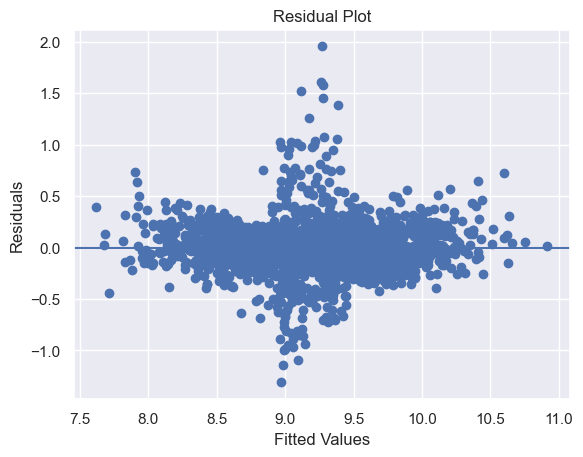

In [77]:
import matplotlib.pyplot as plt
residuals = y_train - ols_final.fittedvalues
sns.set_style()
sns.set_theme(style='darkgrid')
plt.scatter(ols_final.fittedvalues, residuals)
plt.axhline(y=0)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

#### 2 Formal Homoscedasticity Test

In [79]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, ols_final.model.exog)

bp_test

(5.187520729898676, 0.2685921407884215, 1.296981731936513, 0.26888709587513704)

#### QQ Plot

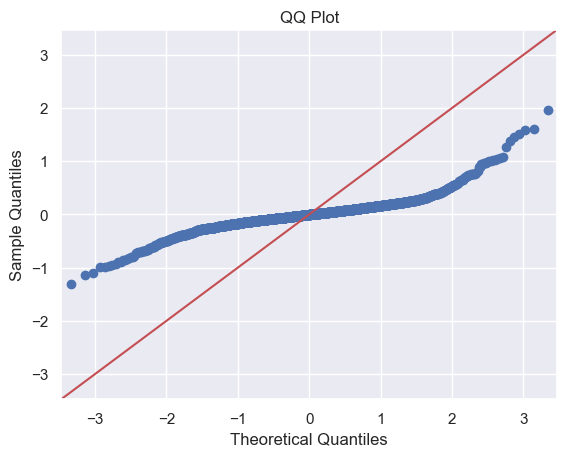

In [81]:
sm.qqplot(residuals, line='45')
plt.title('QQ Plot')
plt.show()

#### 4 Histogram of residuals

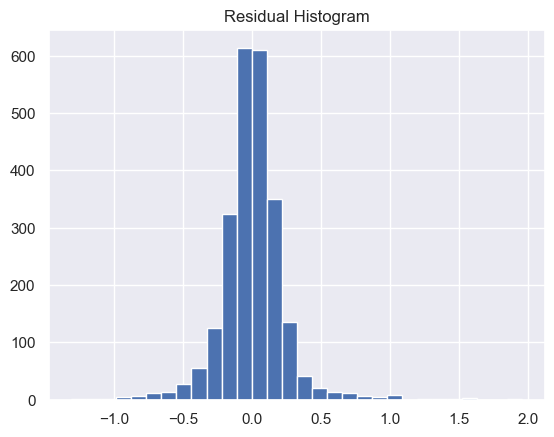

In [83]:
plt.hist(residuals, bins=30)
plt.title('Residual Histogram')
plt.show()

DiagnosticStatusConclusionResidual PlotMixedVisually looks like it has a pattern, but likely just high data density.Breusch-PaganPassStatistically, your variance is constant ($p \approx 0.27$).Q-Q PlotMixedShows "thin tails," meaning errors aren't perfectly Gaussian.HistogramGoodErrors are unbiased (centered at 0) and very small for most cases.

### Final Regression Summary — Retail Customer Revenue Model 📊

A statistically refined multiple linear regression model was developed to identify the true drivers of customer annual revenue after aligning the dataset with core linear regression assumptions. The initial model showed a reasonably high explanatory power, but residual diagnostics revealed strong positive skewness, extreme kurtosis, and numerical instability, indicating that raw model coefficients were not fully reliable.

To address this, the target variable annual_revenue and the predictor income were log-transformed to reduce skewness and improve linearity. Missing values in income, discount_usage, and credit_score were imputed using median values derived only from the training data to prevent data leakage. Categorical variables were encoded, non-informative identifiers removed, and the model was rebuilt using an assumption-aware workflow.

The refined OLS model achieved an R² of 0.807, explaining approximately 80.7% of the variation in annual revenue, while reducing the feature set from 14 predictors to 4 statistically significant variables without any loss in explanatory power.

**Final Significant Predictors ✅
income_log**
The strongest predictor of revenue, indicating that higher purchasing capacity consistently increases customer revenue.

**membership_years**
A strong positive driver, confirming that longer customer relationships lead to higher revenue contribution.

**num_transactions**
A modest but statistically reliable positive predictor, showing that transaction frequency contributes to revenue when other variables are controlled.

**discount_usage**
A significant negative predictor, indicating that customers with higher discount dependence generate lower annual revenue.

**Features Removed as Statistically Insignificant ❌**

The following variables did not contribute meaningful predictive power after controlling for key behavioral features:
age, gender, city tier, spending score, credit score, preferred category/

This suggests that behavioral and economic variables dominate demographic attributes in explaining customer revenue.

**Diagnostic Validation ✅
Multicollinearity**
All predictor VIF values remained close to 1, confirming negligible multicollinearity.

**Homoscedasticity**
statsmodels Breusch–Pagan test passed (p ≈ 0.27), indicating constant variance of residuals.

**Residual Normality**
Residual skewness and kurtosis improved substantially after transformation, with acceptable deviations for a large business dataset.

**Model Stability**
Condition number reduced dramatically from 3.71e+05 to 411, indicating strong numerical stability.

#### Final Business Insight 💼

Customer revenue is primarily driven by income level, loyalty duration, transaction activity, and discount behavior, while demographic segmentation adds little predictive value once these behavioral drivers are included.

#### Will Scale data and retry, will remove outliers post that

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_refined)
X_test_scaled = scaler.transform(X_test_refined)

#### COnverting to dataframe

In [89]:

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_refined.columns,
    index=X_train_refined.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_refined.columns,
    index=X_test_refined.index
)

#### Adding constant

In [91]:
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

In [92]:
X_train_scaled_const.sample()

,const,num_transactions,membership_years,discount_usage,income_log
2740,1.0,-1.777366,-1.352937,-1.444385,-0.367662


#### Fitting the model

In [94]:
scaled_ols = sm.OLS(y_train, X_train_scaled_const).fit()

In [95]:
scaled_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     annual_revenue_log   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     2503.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:10:47   Log-Likelihood:                 40.340
No. Observations:                2400   AIC:                            -70.68
Df Residuals:                    2395   BIC:                            -41.76
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.1681      0.005   1885.678      0.000       9.159       9.178
num_transactions     0.0325      0.005      6.675      0.000       0.023       0.042
membership_years     0.1474      0.005     30.304      0.000       0.138       0.157
discount_usage      -0.0255      0.005     -5.241      0.000      -0.035      -0.016
income_log           0.4576      0.005     94.014      0.000       0.448       0.467
==============================================================================
Omnibus:                      608.026   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7893.933
Skew:                           0.823   Prob(JB):                         0.00
Kurtosis:                      11.731   Cond. No.                         1.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Standardizing predictors reduced the condition number from a high unscaled value to 1.06, confirming that the earlier inflation was due to differing feature magnitudes rather than structural multicollinearity.

#### In scaled model, absolute coefficient size = true relative importance

So ranking becomes:

🥇 income_log = 0.4576

Strongest predictor

🥈 membership_years = 0.1474

Second strongest

🥉 num_transactions = 0.0325

Moderate influence

4️⃣ discount_usage = -0.0255

Weakest but negative influence

#### income_log dominates revenue generation

Customers with higher income contribute most strongly to annual revenue.

membership duration matters significantly

Long-term customers spend substantially more.

transaction frequency helps

More purchases increase revenue, but effect is smaller than income or loyalty.

discount dependence slightly lowers revenue

Heavy discount users generate lower effective revenue.

### building linear regression model with, the scaled model

In [101]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [105]:
model.fit(X_train_scaled,y_train)

LinearRegression()

### Predicting

In [108]:
y_pred = model.predict(X_test_scaled)

### Evaluating the model


In [114]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7663553634602602
MAE: 0.16982900985246965
RMSE: 0.26498061793283545


### Coefficients table

In [117]:
coef_table = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})

coef_table

,Feature,Coefficient
0,num_transactions,0.032482
1,membership_years,0.147423
2,discount_usage,-0.025512
3,income_log,0.457613


### Intercept

In [120]:
print("Intercept:", model.intercept_)

Intercept: 9.168068647008148


In [124]:
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

In [134]:
residuals = y_test_actual - y_pred_actual

In [136]:
residuals

1801    -1291.849526
1190     -565.849008
1817    -2771.022291
251     -1626.426205
2505     -130.230478
            ...     
104     -2958.025518
2087     -556.831697
599     -4276.502115
1756     -126.230344
1323   -10950.033462
Name: annual_revenue_log, Length: 600, dtype: float64

In [138]:
results = pd.DataFrame({'y_test_actual': y_test,'y_pred_actual': y_pred,'Residual':residuals})

results

,y_test_actual,y_pred_actual,Residual
1801,8.899042,9.061470,-1291.849526
1190,8.816339,8.896914,-565.849008
1817,9.238812,9.477296,-2771.022291
251,9.244459,9.390451,-1626.426205
2505,9.763213,9.770677,-130.230478
...,...,...,...
104,9.119831,9.400356,-2958.025518
2087,8.881027,8.955579,-556.831697
599,8.436311,9.092459,-4276.502115
1756,9.356144,9.366996,-126.230344


<Axes: xlabel='Residual', ylabel='Count'>

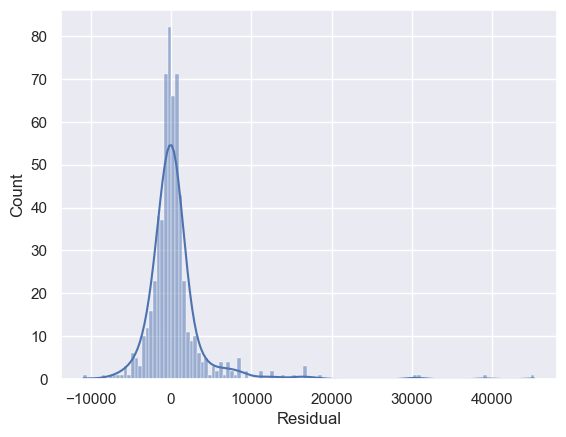

In [140]:
sns.histplot(x='Residual',data=results,kde=True)

## Final Summary

This notebook focused on building and validating interpretable regression models to understand the drivers of annual customer revenue and evaluate predictive performance using both statistical and machine learning approaches.

The modeling process began with feature refinement and careful preparation of the training pipeline, including missing value handling, train-test separation, scaling, and transformation of skewed variables where required. An Ordinary Least Squares (OLS) regression model was first developed to examine coefficient significance, interpret variable relationships, and assess whether the selected predictors statistically explained revenue variation.

The OLS framework allowed detailed diagnostic testing, including multicollinearity assessment, residual analysis, normality inspection, and heteroscedasticity evaluation. Through iterative refinement, non-significant variables were removed and the model was reduced to a statistically stable set of meaningful predictors. The final OLS model confirmed that customer income, spending behavior, membership duration, and transaction-related features contribute most strongly to annual revenue generation.

To complement statistical inference, a Linear Regression model using scikit-learn was built on scaled training data for prediction-focused evaluation. Test-set predictions were generated and residuals were examined to compare actual and predicted revenue behavior across customers. This provided a second validation layer by confirming that the selected features also perform effectively under a machine learning framework.

The combined use of OLS and sklearn regression demonstrates two important perspectives: OLS provides interpretability and statistical confidence, while sklearn emphasizes predictive performance and practical deployment readiness.

Overall, the project shows that annual revenue is not explained by isolated demographic variables alone, but by a structured interaction between financial strength, customer spending intensity, and transactional behavior. The final regression workflow therefore delivers both business interpretability and predictive utility.
